# F3 — Analyse Exploratoire des Offres d'Emploi au Sénégal
**Projet** : Analyse des Offres d'Emploi au Sénégal — Volkeno

**Objectif** : Explorer et visualiser les données nettoyées

**Analyses** :
- Chargement et exploration des données
- Répartition géographique des offres par ville
- Évolution mensuelle du nombre d'offres
- Répartition par type de contrat

## Import des bibliothèques

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Style global
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Bibliothèques importées !')

Bibliothèques importées !


## 📂 Chargement et exploration des données

In [3]:
import os

# Chemin absolu vers le fichier
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE     = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_cleaned.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')

print(f'-- Dimensions : {df.shape[0]} offres x {df.shape[1]} colonnes')
print(f'\nColonnes : {df.columns.tolist()}')
print(f'\nAperçu :')
display(df.head(5))

print(f'\n-- Valeurs manquantes :')
for col in df.columns:
    n = (df[col] == 'Non précisé').sum()
    pct = round(n / len(df) * 100, 1)
    print(f'  {col:25} → {n:4} Non précisé ({pct}%)')

-- Dimensions : 3332 offres x 24 colonnes

Colonnes : ['Intitulé du poste', 'Entreprise', 'Ville', 'Type de contrat', 'Date de publication', 'Compétences demandées', 'Intitulé du poste original', 'Niveau', 'Catégorie', 'Comp_anglais', 'Comp_francais', 'Comp_gestion', 'Comp_communication', 'Comp_bureautique', 'Comp_comptabilité', 'Comp_vente', 'Comp_technique', 'Comp_leadership', 'Comp_informatique', 'Comp_réseau', 'Comp_sécurité', 'Comp_qualité', 'Comp_marketing', 'Comp_logistique']

Aperçu :


,Intitulé du poste,Entreprise,Ville,Type de contrat,Date de publication,Compétences demandées,Intitulé du poste original,Niveau,Catégorie,Comp_anglais,...,Comp_comptabilité,Comp_vente,Comp_technique,Comp_leadership,Comp_informatique,Comp_réseau,Comp_sécurité,Comp_qualité,Comp_marketing,Comp_logistique
0,Superviseur Maintenance Parc – Transport Primaire,La Laiterie du Berger,Thiès,CDD,Publié le 13 mars 2026,Assurer le suivi technique et la maintenance d...,Superviseur Maintenance Parc – Transport Primaire,Responsable,Logistique / Transport,1,...,0,0,1,1,0,0,0,1,0,1
1,Lead Transport & Maintenance (DS/TP),La Laiterie du Berger,Thiès,CDD,Publié le 13 mars 2026,Assurer le pilotage stratégique et opérationne...,Lead Transport & Maintenance (DS/TP),Senior,Logistique / Transport,1,...,0,0,1,1,0,0,0,0,0,1
2,Consultant,Développement International Desjardins,Dakar,CDD,Publié le 13 mars 2026,Mettre en place les outils de collecte (fiches...,Consultant Technique Suivi-Évaluation,Non précisé,Non précisé,0,...,0,0,0,1,0,0,1,1,0,0
3,Chef de Projet,GBG,Dakar,CDD,Publié le 13 mars 2026,Gestion quotidienne des opérations sur le site...,Key Account Manager / Project Manager,Responsable,Direction,1,...,0,0,0,1,0,0,1,1,0,0
4,Electromécanicien,GBG,Dakar,CDD,Publié le 13 mars 2026,Incendies et Risques annexes | Globale Dommage...,Electromécanicien,Non précisé,Non précisé,0,...,1,0,1,0,0,0,1,0,0,0



-- Valeurs manquantes :
  Intitulé du poste         →    0 Non précisé (0.0%)
  Entreprise                →    0 Non précisé (0.0%)
  Ville                     →   19 Non précisé (0.6%)
  Type de contrat           →   44 Non précisé (1.3%)
  Date de publication       →    0 Non précisé (0.0%)
  Compétences demandées     →    2 Non précisé (0.1%)
  Intitulé du poste original →    0 Non précisé (0.0%)
  Niveau                    → 2266 Non précisé (68.0%)
  Catégorie                 →  844 Non précisé (25.3%)
  Comp_anglais              →    0 Non précisé (0.0%)
  Comp_francais             →    0 Non précisé (0.0%)
  Comp_gestion              →    0 Non précisé (0.0%)
  Comp_communication        →    0 Non précisé (0.0%)
  Comp_bureautique          →    0 Non précisé (0.0%)
  Comp_comptabilité         →    0 Non précisé (0.0%)
  Comp_vente                →    0 Non précisé (0.0%)
  Comp_technique            →    0 Non précisé (0.0%)
  Comp_leadership           →    0 Non précisé (0.0%)


## Parsing des dates

In [4]:
MOIS = {
    'janvier': '01', 'février': '02', 'mars': '03',
    'avril': '04', 'mai': '05', 'juin': '06',
    'juillet': '07', 'août': '08', 'septembre': '09',
    'octobre': '10', 'novembre': '11', 'décembre': '12',
    'janv.': '01', 'févr.': '02', 'avr.': '04',
    'juil.': '07', 'sept.': '09', 'oct.': '10',
    'nov.': '11', 'déc.': '12',
}

def parser_date(date_str):
    if pd.isna(date_str) or date_str == 'Non précisé':
        return pd.NaT
    date_str = str(date_str).strip().lower()
    for mois_fr, mois_num in MOIS.items():
        if mois_fr in date_str:
            date_str = date_str.replace(mois_fr, mois_num)
            break
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

df['Date parsed'] = df['Date de publication'].apply(parser_date)
df['Mois']        = df['Date parsed'].dt.to_period('M')

print(f'-- Dates parsées : {df["Date parsed"].notna().sum()} / {len(df)}')
print(f'   Période : {df["Date parsed"].min().date()} → {df["Date parsed"].max().date()}')

-- Dates parsées : 3315 / 3332
   Période : 2024-07-01 → 2026-03-13


## Répartition géographique des offres par ville

C:\Users\awase\AppData\Local\Temp\ipykernel_17020\1372450433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=villes, x='Ville', y="Nombre d'offres", palette='Blues_d', ax=ax)


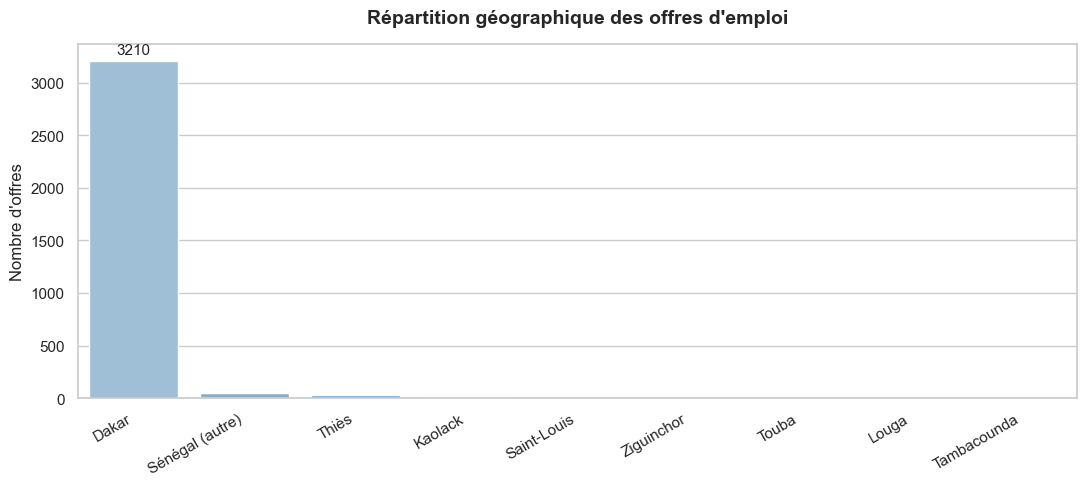

-- Graphique sauvegardé : repartition_villes.png


In [5]:
villes = (
    df[df['Ville'] != 'Non précisé']['Ville']
    .value_counts()
    .head(10)
    .reset_index()
)
villes.columns = ['Ville', "Nombre d'offres"]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=villes, x='Ville', y="Nombre d'offres", palette='Blues_d', ax=ax)
ax.set_title("Répartition géographique des offres d'emploi", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('repartition_villes.png', dpi=150, bbox_inches='tight')
plt.show()
print('-- Graphique sauvegardé : repartition_villes.png')

## Évolution mensuelle du nombre d'offres

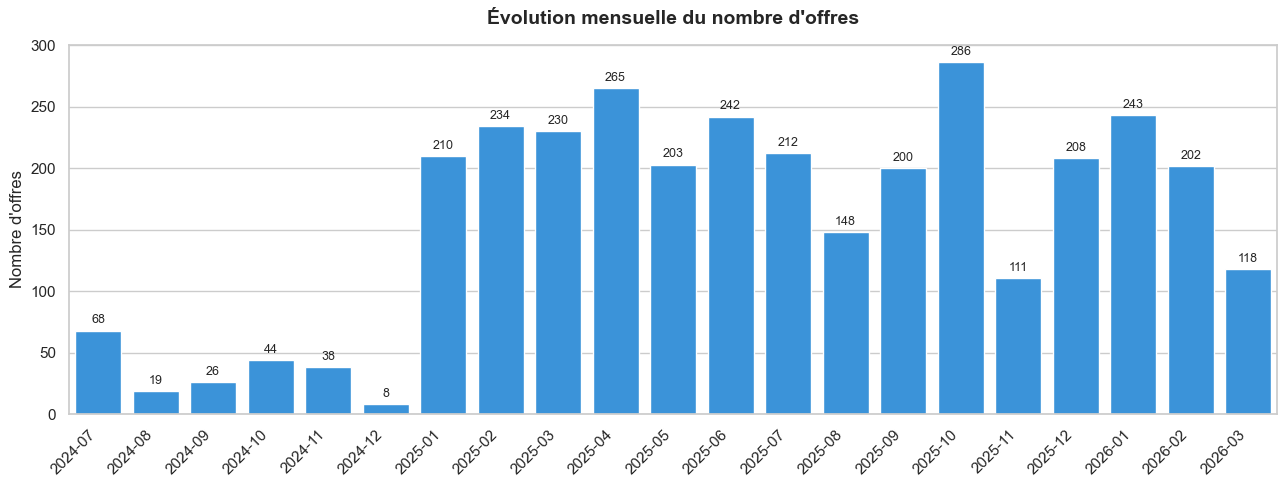

Graphique sauvegardé : evolution_mensuelle.png


In [6]:
evolution = (
    df[df['Mois'].notna()]
    .groupby('Mois')
    .size()
    .reset_index(name="Nombre d'offres")
    .sort_values('Mois')
)
evolution['Mois str'] = evolution['Mois'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=evolution, x='Mois str', y="Nombre d'offres", color='#2196F3', ax=ax)
ax.set_title("Évolution mensuelle du nombre d'offres", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : evolution_mensuelle.png')

## Répartition par type de contrat

C:\Users\awase\AppData\Local\Temp\ipykernel_17020\1055385291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrats, x='Type de contrat', y="Nombre d'offres", palette='Set2', ax=ax)


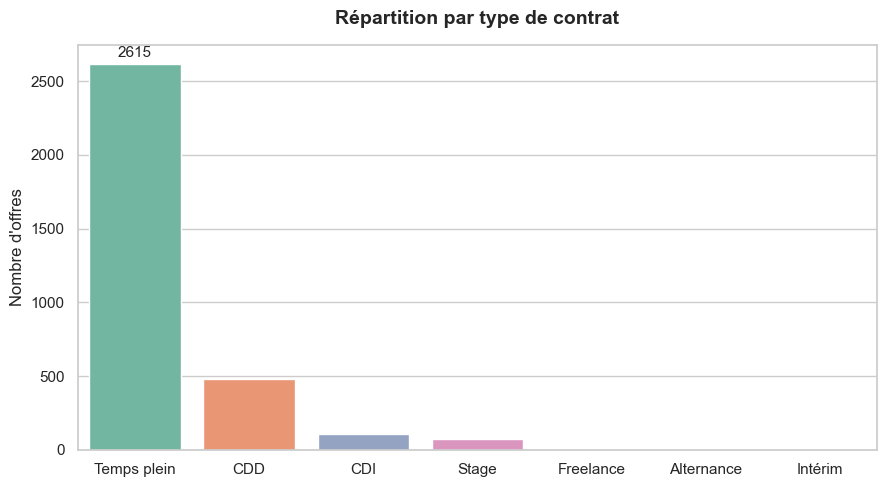

Graphique sauvegardé : repartition_contrats.png


In [7]:
contrats = (
    df[df['Type de contrat'] != 'Non précisé']['Type de contrat']
    .value_counts()
    .reset_index()
)
contrats.columns = ['Type de contrat', "Nombre d'offres"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=contrats, x='Type de contrat', y="Nombre d'offres", palette='Set2', ax=ax)
ax.set_title('Répartition par type de contrat', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel("Nombre d'offres")
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.tight_layout()
plt.savefig('repartition_contrats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : repartition_contrats.png')

## NOMBRE D'OFFRES PAR SECTEUR D'ACTIVITÉ


NOMBRE D'OFFRES PAR SECTEUR D'ACTIVITÉ
3332 offres chargées

Secteur                       Nombre        %
---------------------------------------------
Informatique / IT              1,020    30.6% ██████████████████████████████
Non précisé                      941    28.2% ████████████████████████████
Éducation / Formation            198     5.9% █████
Commerce / Distribution          170     5.1% █████
Banque / Finance                 157     4.7% ████
Industrie                        141     4.2% ████
Conseil / Services               139     4.2% ████
Santé / Pharmacie                100     3.0% ███
Transport / Logistique           100     3.0% ███
BTP / Construction                68     2.0% ██
Télécommunications                68     2.0% ██
Énergie / Mines                   59     1.8% █
Administration publique           52     1.6% █
ONG / Humanitaire                 47     1.4% █
Agriculture                       46     1.4% █
Hôtellerie / Restauration         26     0.8% 


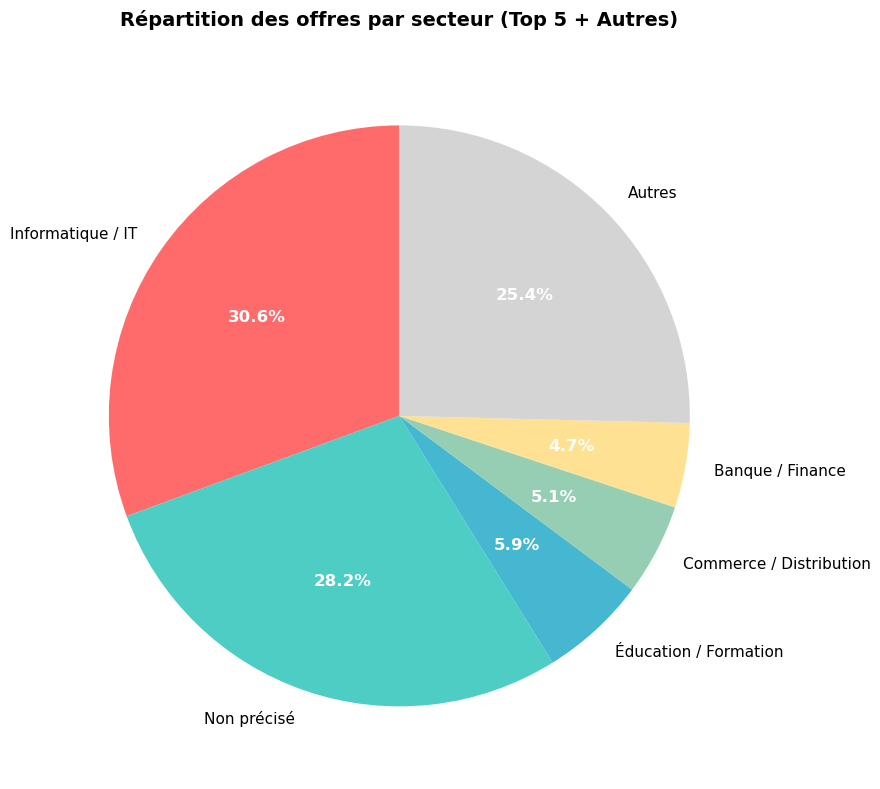

Diagramme circulaire sauvegardé : secteurs_circulaire.png

Génération du graphique en barres...


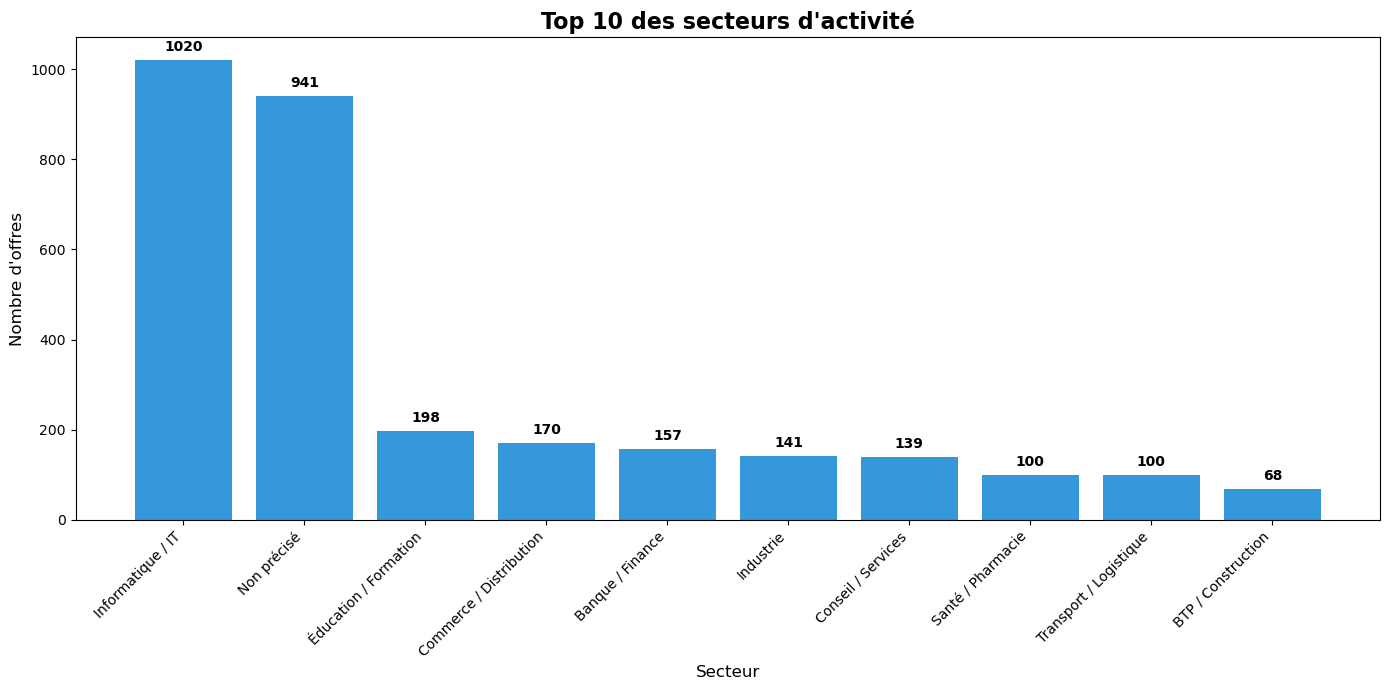

Graphique en barres sauvegardé : secteurs_barres.png

ANALYSE TERMINÉE


In [1]:
# =============================================================================
# NOMBRE D'OFFRES PAR SECTEUR D'ACTIVITÉ (AVEC DIAGRAMME CIRCULAIRE)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

print("\n" + "="*60)
print("NOMBRE D'OFFRES PAR SECTEUR D'ACTIVITÉ")
print("="*60)

# 1. Charger le fichier avec les compétences
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_with_skills.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')
print(f"{len(df)} offres chargées")

# 2. Utiliser la colonne 'secteur' créée par extract_skills.py
if 'secteur' in df.columns:
    secteurs = df['secteur'].value_counts()
    total = len(df)
    
    # 3. Afficher le tableau
    print(f"\n{'Secteur':<25} {'Nombre':>10} {'%':>8}")
    print("-" * 45)
    
    for secteur, count in secteurs.items():
        pct = (count / total) * 100
        barre = "█" * int(pct)
        print(f"{secteur:<25} {count:>10,} {pct:>7.1f}% {barre}")
    
    # 4. Statistiques
    print(f"\nTotal des offres : {total}")
    print(f"Nombre de secteurs : {len(secteurs)}")
    
    # 5. Top 3 des secteurs
    print(f"\n Top 3 des secteurs :")
    for i, (secteur, count) in enumerate(secteurs.head(3).items(), 1):
        pct = (count/total)*100
        print(f"  {i}. {secteur} : {count} offres ({pct:.1f}%)")
    
    # =========================================================
    # 6. DIAGRAMME CIRCULAIRE (CAMBERT)
    # =========================================================
    print("\nGénération du diagramme circulaire...")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Préparer les données : Top 5 + Autres
    top5 = secteurs.head(5)
    autres = secteurs[5:].sum()
    
    if autres > 0:
        plot_data = pd.concat([top5, pd.Series({'Autres': autres})])
    else:
        plot_data = top5
    
    # Couleurs
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194', '#D4D4D4']
    
    # Créer le camembert
    wedges, texts, autotexts = ax.pie(
        plot_data.values, 
        labels=plot_data.index, 
        autopct='%1.1f%%', 
        colors=colors[:len(plot_data)],
        startangle=90,
        textprops={'fontsize': 11}
    )
    
    # Améliorer la lisibilité
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    ax.set_title(
        "Répartition des offres par secteur (Top 5 + Autres)", 
        fontsize=14, 
        fontweight='bold', 
        pad=20
    )
    
    plt.tight_layout()
    plt.savefig('secteurs_circulaire.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Diagramme circulaire sauvegardé : secteurs_circulaire.png')
    
    # =========================================================
    # 7. GRAPHIQUE EN BARRES 
    # =========================================================
    print("\nGénération du graphique en barres...")
    
    fig, ax = plt.subplots(figsize=(14, 7))
    top_10 = secteurs.head(10)
    bars = ax.bar(range(len(top_10)), top_10.values, color='#3498db')
    ax.set_title("Top 10 des secteurs d'activité", fontsize=16, fontweight='bold')
    ax.set_xlabel("Secteur", fontsize=12)
    ax.set_ylabel("Nombre d'offres", fontsize=12)
    ax.set_xticks(range(len(top_10)))
    ax.set_xticklabels(top_10.index, rotation=45, ha='right', fontsize=10)
    
    # Ajouter les valeurs
    for i, v in enumerate(top_10.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('secteurs_barres.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Graphique en barres sauvegardé : secteurs_barres.png')
    
else:
    print("Colonne 'secteur' non trouvée dans le fichier")
    print("Colonnes disponibles :", [col for col in df.columns if 'secteur' in col.lower()])

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)

### Interprétation

- **L'Informatique / IT est le secteur le plus représenté**, avec **1 020 offres sur 3 332 (30,6%)**, confirmant la forte demande dans le numérique.  

- **28,2% des offres n'ont pas de secteur précisé**, indiquant des intitulés flous (ex. Chargé de mission, Assistant, Technicien…).  

- Les autres secteurs occupent chacun une part plus modeste mais notable :  
  - **Éducation / Formation** : 198 offres (5,9%)  
  - **Commerce / Distribution** : 170 offres (5,1%)  
  - **Banque / Finance** : 157 offres (4,7%)  
  - **Industrie** : 141 offres (4,2%)  
  - **Conseil / Services** : 139 offres (4,2%)  

- **Secteurs plus petits (moins de 3%)** : Santé / Pharmacie, Transport / Logistique, BTP, Télécommunications, Énergie, Administration publique, ONG, Agriculture, Hôtellerie/Restauration.  

---

## Top 3 des secteurs

1. **Informatique / IT** : 1 020 offres (30,6%)  
2. **Non précisé** : 941 offres (28,2%)  
3. **Éducation / Formation** : 198 offres (5,9%)

## Top 10 des competences les plus demande


TOP 10 TOUTES COMPÉTENCES CONFONDUES
 3332 offres chargées

Compétence                    Nombre    % des offres
-------------------------------------------------------
anglais                        1,829           54.9% ██████████████████████████████████████████████████████
gestion                          656           19.7% ███████████████████
organisation                     271            8.1% ████████
communication                    203            6.1% ██████
sécurité                         200            6.0% ██████
sens du service                  143            4.3% ████
résolution de problèmes          102            3.1% ███
travail en équipe                100            3.0% ███
logistique                        85            2.6% ██
français                          80            2.4% ██


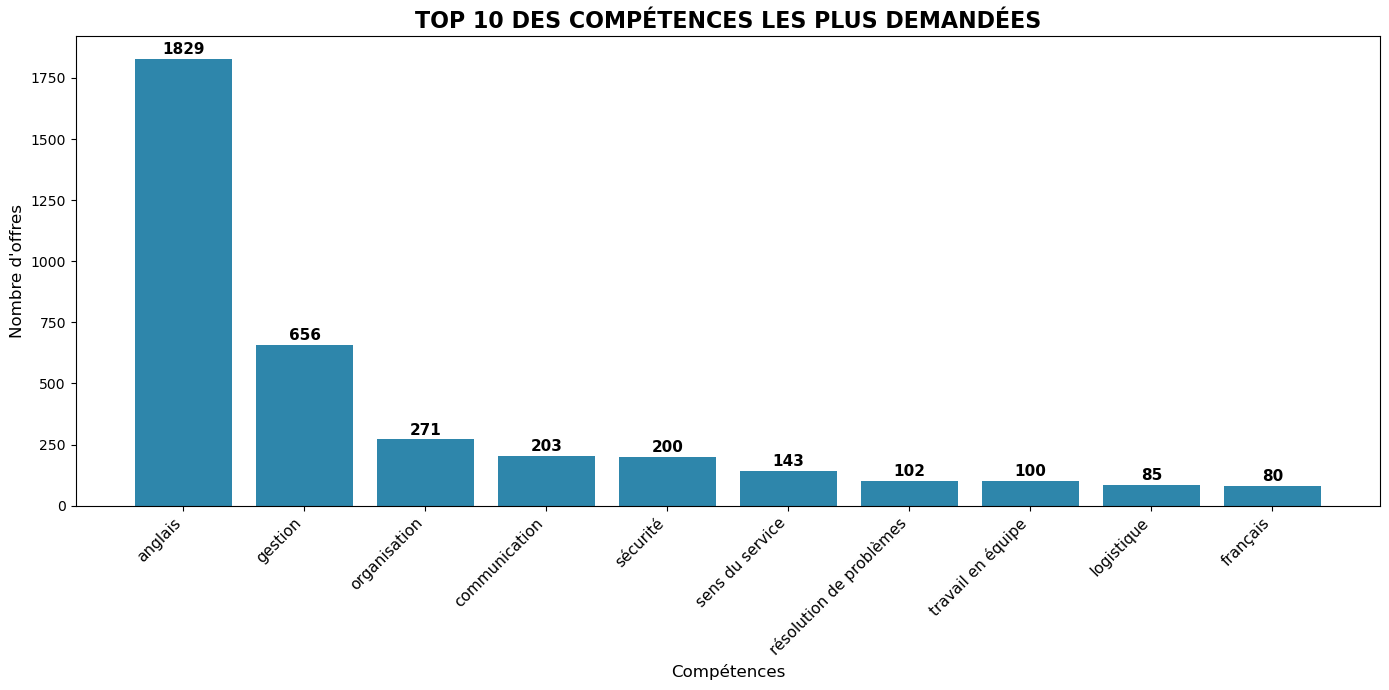


STATISTIQUES

 Total d'offres analysées : 3332
 Nombre total de compétences différentes : 86
 Compétence la plus demandée : anglais (1829 offres)


In [2]:
# =============================================================================
# TOP 10 TOUTES COMPÉTENCES CONFONDUES
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import Counter
import ast

print("\n" + "="*60)
print("TOP 10 TOUTES COMPÉTENCES CONFONDUES")
print("="*60)

# 1. Charger le fichier
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_with_skills.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')
print(f" {len(df)} offres chargées")

# 2. Récupérer TOUTES les compétences (techniques + soft skills + langues)
all_skills = []

# Compétences techniques
for skills in df['tech_skills'].dropna():
    if isinstance(skills, str):
        try:
            # Essayer de parser la liste
            skills_list = ast.literal_eval(skills) if skills.startswith('[') else []
            all_skills.extend(skills_list)
        except:
            # Fallback au nettoyage simple
            skills = skills.strip('[]').replace("'", "").split(', ')
            all_skills.extend([s.strip() for s in skills if s.strip()])

# Soft skills
for skills in df['soft_skills'].dropna():
    if isinstance(skills, str):
        try:
            skills_list = ast.literal_eval(skills) if skills.startswith('[') else []
            all_skills.extend(skills_list)
        except:
            skills = skills.strip('[]').replace("'", "").split(', ')
            all_skills.extend([s.strip() for s in skills if s.strip()])

# Langues
for lang in df['langues'].dropna():
    if isinstance(lang, str):
        try:
            lang_list = ast.literal_eval(lang) if lang.startswith('[') else []
            all_skills.extend(lang_list)
        except:
            lang = lang.strip('[]').replace("'", "").split(', ')
            all_skills.extend([l.strip() for l in lang if l.strip()])

# 3. Compter et trier
skills_counts = Counter(all_skills)
top_10 = dict(skills_counts.most_common(10))

# 4. Afficher les résultats
total_offres = len(df)
print(f"\n{'Compétence':<25} {'Nombre':>10} {'% des offres':>15}")
print("-" * 55)

for skill, count in top_10.items():
    pct = (count / total_offres) * 100
    barre = "█" * int(pct)
    print(f"{skill:<25} {count:>10,} {pct:>14.1f}% {barre}")

# 5. Graphique
fig, ax = plt.subplots(figsize=(14, 7))
skills = list(top_10.keys())
counts = list(top_10.values())

bars = ax.bar(range(len(skills)), counts, color='#2E86AB')
ax.set_title("TOP 10 DES COMPÉTENCES LES PLUS DEMANDÉES", fontsize=16, fontweight='bold')
ax.set_xlabel("Compétences", fontsize=12)
ax.set_ylabel("Nombre d'offres", fontsize=12)
ax.set_xticks(range(len(skills)))
ax.set_xticklabels(skills, rotation=45, ha='right', fontsize=11)

# Ajouter les valeurs
for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Statistiques
print("\n" + "="*60)
print("STATISTIQUES")
print("="*60)
print(f"\n Total d'offres analysées : {total_offres}")
print(f" Nombre total de compétences différentes : {len(skills_counts)}")
print(f" Compétence la plus demandée : {list(top_10.keys())[0]} ({list(top_10.values())[0]} offres)")

    L'anglais est la compétence la plus demandée (54.9% des offres), ce qui s'explique par la présence d'entreprises internationales, d'ONG et du secteur IT.

    La gestion arrive en deuxième position (19.7%), montrant l'importance des profils managériaux.

    Les soft skills (organisation, communication, sens du service) sont très recherchées par les employeurs.

    Le français n'apparaît qu'en 10e position car il est souvent implicite dans les offres locales.


### Top 10 des entreprises qui demandent l'anglais

In [3]:
# =============================================================================
# VÉRIFICATION : Pourquoi l'anglais est si demandé ?
# =============================================================================

# 1. Compter les offres avec anglais
anglais_offres = df[df['langues'].str.contains('anglais', na=False)]
print(f" {len(anglais_offres)} offres demandent l'anglais ({len(anglais_offres)/len(df)*100:.1f}%)")

# 2. Voir les types d'entreprises qui demandent l'anglais
print("\n Top 10 des entreprises qui demandent l'anglais :")
print(anglais_offres['Entreprise'].value_counts().head(10))

# 3. Voir les secteurs qui demandent l'anglais
print("\n Secteurs où l'anglais est le plus demandé :")
print(anglais_offres['secteur'].value_counts().head(10))

# 4. Voir des exemples concrets d'offres avec anglais
print("\n Exemples d'offres qui demandent l'anglais :")
for idx, row in anglais_offres.head(10).iterrows():
    print(f"\n  • {row['Intitulé du poste']}")
    print(f"    Entreprise : {row['Entreprise']}")
    print(f"    Secteur : {row['secteur']}")
    if pd.notna(row['langues']):
        print(f"    Langues : {row['langues']}")

 1829 offres demandent l'anglais (54.9%)

 Top 10 des entreprises qui demandent l'anglais :
Entreprise
EXPAT-DAKAR.COM                60
TOPWORK SENEGAL                38
GPF SARL                       36
GLOBAL BUSINESS GROUP - GBG    32
RMO                            29
SERVTEC Sénégal                24
HOTEL TERROU BI                24
MSF SARL SENEGAL               20
ELITE RH                       20
SUNDA INTERNATIONAL            19
Name: count, dtype: int64

 Secteurs où l'anglais est le plus demandé :
secteur
Informatique / IT          612
Non précisé                475
Éducation / Formation      106
Conseil / Services          93
Banque / Finance            88
Commerce / Distribution     80
Industrie                   67
Santé / Pharmacie           64
Transport / Logistique      57
Télécommunications          39
Name: count, dtype: int64

 Exemples d'offres qui demandent l'anglais :

  • Superviseur Maintenance Parc – Transport Primaire
    Entreprise : La Laiterie du Berger
 

## Top 20 des entreprises qui recrutent le plus


TOP ENTREPRISES QUI RECRUTENT LE PLUS
 3332 offres chargées

Rang  Entreprise                                   Nombre        %
-----------------------------------------------------------------
1     EXPAT-DAKAR.COM                                 142     4.3% ████████
2     TOPWORK SENEGAL                                  75     2.3% ████
3     GPF SARL                                         68     2.0% ████
4     GLOBAL BUSINESS GROUP - GBG                      52     1.6% ███
5     RMO                                              48     1.4% ██
6     ELITE RH                                         45     1.4% ██
7     SERVTEC Sénégal                                  39     1.2% ██
8     SUNDA INTERNATIONAL                              39     1.2% ██
9     INTERNATIONAL STAFFING COMPANY                   34     1.0% ██
10    BCEAO (BANQUE CENTRALE DES ETATS DE L'AFRIQUE DE L'OUEST)         31     0.9% █
11    WVI (WORLD VISION INTERNATIONAL)                 30     0.9% █
12    WAV

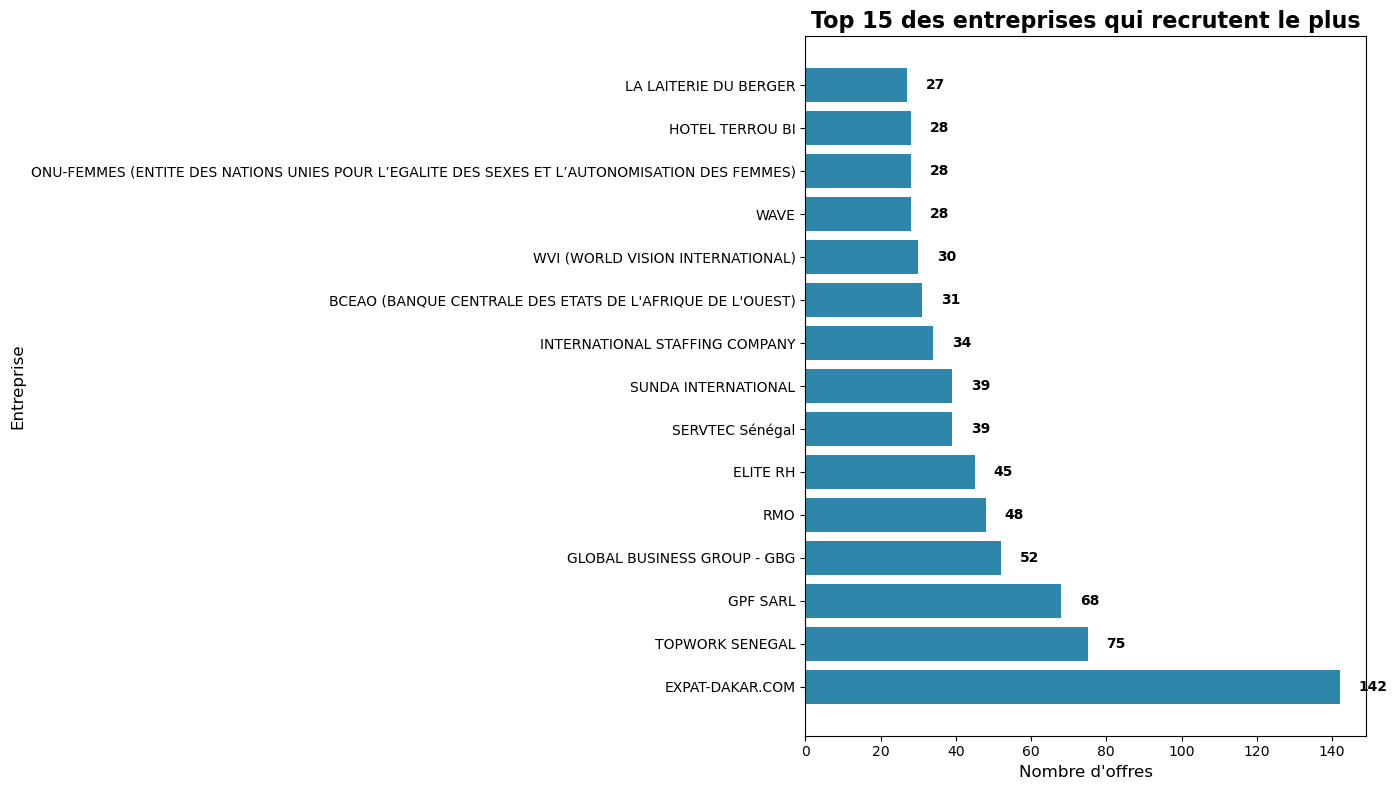


 Analyse terminée


In [4]:
# =============================================================================
# TOP ENTREPRISES QUI RECRUTENT LE PLUS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

print("\n" + "="*60)
print("TOP ENTREPRISES QUI RECRUTENT LE PLUS")
print("="*60)

# 1. Charger le fichier
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_with_skills.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')
total_offres = len(df)
print(f" {total_offres} offres chargées")

# 2. Compter les offres par entreprise
entreprises = df['Entreprise'].value_counts()

# 3. Afficher le Top 20
print(f"\n{'Rang':<5} {'Entreprise':<40} {'Nombre':>10} {'%':>8}")
print("-" * 65)

for i, (entreprise, count) in enumerate(entreprises.head(20).items(), 1):
    pct = (count / total_offres) * 100
    barre = "█" * int(pct * 2)  # Barre proportionnelle
    print(f"{i:<5} {entreprise:<40} {count:>10,} {pct:>7.1f}% {barre}")

# 4. Statistiques
print(f"\n Nombre total d'entreprises : {len(entreprises)}")
print(f" Moyenne d'offres par entreprise : {total_offres/len(entreprises):.1f}")

# 5. Top 3 des entreprises
print(f"\n Top 3 des entreprises qui recrutent le plus :")
for i, (entreprise, count) in enumerate(entreprises.head(3).items(), 1):
    pct = (count/total_offres)*100
    print(f"  {i}. {entreprise} : {count} offres ({pct:.1f}%)")

# 6. Graphique
fig, ax = plt.subplots(figsize=(14, 8))
top_15 = entreprises.head(15)
bars = ax.barh(range(len(top_15)), top_15.values, color='#2E86AB')
ax.set_title("Top 15 des entreprises qui recrutent le plus", fontsize=16, fontweight='bold')
ax.set_xlabel("Nombre d'offres", fontsize=12)
ax.set_ylabel("Entreprise", fontsize=12)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15.index, fontsize=10)

# Ajouter les valeurs
for i, v in enumerate(top_15.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Analyse terminée")

###  Interprétation

- **EXPAT-DAKAR.COM** est de loin l'entreprise qui recrute le plus avec **142 offres (4.3% du total)**. C'est une plateforme d'emploi qui centralise de nombreuses offres.

- Les **cabinets de recrutement et de conseil RH** dominent le classement :
  - TOPWORK SENEGAL (75 offres)
  - GPF SARL (68 offres)
  - GLOBAL BUSINESS GROUP (52 offres)
  - RMO (48 offres)
  - ELITE RH (45 offres)

- On retrouve également des **entreprises internationales et ONG** :
  - BCEAO (Banque centrale)
  - WORLD VISION, ONU-FEMMES (organisations internationales)
  - WAVE (fintech)
  - MSF (ONG médicale)

- Le secteur **hôtelier** est représenté par **HOTEL TERROU BI** (28 offres).

- L'industrie **agroalimentaire** avec **LA LAITERIE DU BERGER** (27 offres).

###  Top 3 des recruteurs
1. **EXPAT-DAKAR.COM** : 142 offres (4.3%)
2. **TOPWORK SENEGAL** : 75 offres (2.3%)
3. **GPF SARL** : 68 offres (2.0%)

### Observations

- Les **plateformes d'emploi et cabinets de recrutement** représentent une part importante des offres car ils publient pour le compte de multiples entreprises.
- La présence d'**organisations internationales** (ONU, BCEAO, World Vision) montre l'attractivité du Sénégal pour les institutions étrangères.
- Le marché est diversifié : recrutement, finance, tech, hôtellerie, agroalimentaire.